# Distributional Counterfactual Explanation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder

from models.mlp import BlackBoxModel

pd.set_option('display.max_columns', None)

%reload_ext autoreload
%autoreload 2

## Read and Process Data

In [2]:
df_ = pd.read_csv('data/hotel_booking/hotel_bookings.csv')
df = df_.copy()
target_name = 'is_canceled'
target = df[target_name]

In [3]:
# Initialize a label encoder
label_encoder = LabelEncoder()
label_mappings = {}


# Convert categorical columns to numerical representations using label encoding
for column in df.columns:
    if df[column].dtype == 'object':
        # Handle missing values by filling with a placeholder and then encoding
        df[column] = df[column].fillna('Unknown')
        df[column] = label_encoder.fit_transform(df[column])
        label_mappings[column] = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))



# For columns with NaN values that are numerical, we will impute them with the median of the column
for column in df.columns:
    if df[column].isna().any():
        median_val = df[column].median()
        df[column].fillna(median_val, inplace=True)

# Display the first few rows of the transformed dataframe
df.head()


C:\Users\Yikai Gu\AppData\Local\Temp\ipykernel_29228\4134585501.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(median_val, inplace=True)
C:\Users\Yikai Gu\AppData\Local\Temp\ipykernel_29228\4134585501.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,0,342,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,3,0,14.0,179.0,0,2,0.0,0,0,1,15
1,1,0,737,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,4,0,14.0,179.0,0,2,0.0,0,0,1,15
2,1,0,7,2015,5,27,1,0,1,1,0.0,0,0,59,3,1,0,0,0,0,2,0,0,14.0,179.0,0,2,75.0,0,0,1,46
3,1,0,13,2015,5,27,1,0,1,1,0.0,0,0,59,2,0,0,0,0,0,0,0,0,304.0,179.0,0,2,75.0,0,0,1,46
4,1,0,14,2015,5,27,1,0,2,2,0.0,0,0,59,6,3,0,0,0,0,0,0,0,240.0,179.0,0,2,98.0,0,1,1,76


## Model Training

In [4]:
import os
# True 表示重新训练模型 False 表示加载已有模型
RETRAIN_MODEL = False  
REGENERATE_Y_TARGET = False
REGENERATE_X_INIT = False

X_INIT_PATH = "saved_models/hotel_X_init.pt"
MODEL_PATH = "saved_models/hotel_blackbox_model.pth"
FACTUAL_PATH = "saved_models/hotel_factual_sample.pt"
Y_TARGET_PATH = "saved_models/hotel_y_target.pt"
# 创建保存目录
os.makedirs("saved_models", exist_ok=True)

In [5]:
features = [
    'hotel', 
    'lead_time', 
    'arrival_date_year', 
    'arrival_date_month',
    'arrival_date_week_number', 
    'arrival_date_day_of_month',
    'stays_in_weekend_nights', 
    'stays_in_week_nights', 
    'adults', 
    'children',
    'babies', 
    'meal', 
    'country', 
    'market_segment', 
    'distribution_channel',
    'is_repeated_guest', 
    'previous_cancellations',
    'previous_bookings_not_canceled', 
    'reserved_room_type',
    'assigned_room_type', 
    'booking_changes', 
    'deposit_type', 
    'agent',
    'company', 
    'days_in_waiting_list', 
    'customer_type', 
    'adr',
    'required_car_parking_spaces', 
    'total_of_special_requests'
]

df_X = df[features].copy()
df_y = target

In [6]:
seed = 42

np.random.seed(seed)  # for reproducibility


# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=seed)

std = X_train.std()
mean = X_train.mean()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

# Initialize the model, loss function, and optimizer
model = BlackBoxModel(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# # Training loop
# num_epochs = 100
# for epoch in range(num_epochs):
#     # Forward pass
#     outputs = model(X_train_tensor)
#     loss = criterion(outputs, y_train_tensor)
    
#     # Backward pass and optimization
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

# # Evaluate on test set
# model.eval()
# with torch.no_grad():
#     test_outputs = model(X_test_tensor)
#     test_loss = criterion(test_outputs, y_test_tensor)

#     # Convert outputs to binary using 0.5 as threshold
#     y_pred_tensor = (test_outputs > 0.5).float()
#     correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
#     accuracy = correct_predictions / y_test_tensor.shape[0]

# accuracy.item()
if RETRAIN_MODEL:
    print("🔁 Training model from scratch...")

    # 训练 loop
    num_epochs = 100
    for epoch in range(num_epochs):
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 测试
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)

        y_pred_tensor = (test_outputs > 0.5).float()
        correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
        accuracy = correct_predictions / y_test_tensor.shape[0]
        print(f"✅ Final Test Accuracy: {accuracy.item():.4f}")

    # 保存模型
    torch.save(model.state_dict(), MODEL_PATH)

    # 保存解释用样本（固定 factual）
    sample_num = 50
    indice = (X_test.sample(sample_num, random_state=42)).index
    df_explain = X_test.loc[indice]
    torch.save(df_explain, FACTUAL_PATH)
    print("✅ Model and factual sample saved.")

else:
    print("📦 Loading model and fixed factual sample...")
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
    df_explain = torch.load(FACTUAL_PATH)
    print("✅ Loaded.")

📦 Loading model and fixed factual sample...
✅ Loaded.


## Counterfactual Explanation

In [7]:
sample_num = 100
delta = 0.1
alpha = 0.05
N=10
explain_columns = [
    'lead_time', 
    'booking_changes', 
    'total_of_special_requests',
    'is_repeated_guest',
]

indice = (X_test.sample(sample_num)).index

df_explain = X_test.loc[indice]

# X = X_test.loc[indice].values
y = model(torch.FloatTensor(df_explain.values))

# 加载或生成 y_target
if REGENERATE_Y_TARGET:
    sample_num = df_explain.shape[0]
    y_target = torch.distributions.beta.Beta(0.1, 0.9).sample((sample_num,))
    torch.save(y_target, Y_TARGET_PATH)
    print("✅ Regenerated and saved y_target.")
else:
    y_target = torch.load(Y_TARGET_PATH)
    print("📦 Loaded y_target.")
# y_target = torch.distributions.beta.Beta(0.1, 0.9).sample((sample_num,))

if REGENERATE_X_INIT:
    noise = torch.randn_like(torch.FloatTensor(df_explain.values)[:, [df_explain.columns.get_loc(c) for c in explain_columns]]) * 0.01
    X_init = torch.FloatTensor(df_explain.values).clone()
    X_init[:, [df_explain.columns.get_loc(c) for c in explain_columns]] += noise
    torch.save(X_init, X_INIT_PATH)
else:
    X_init = torch.load(X_INIT_PATH)

y_true = y_test.loc[indice]

📦 Loaded y_target.


In [8]:
category = ['is_repeated_guest']
continuous = ['lead_time', 'booking_changes', 'total_of_special_requests', 'is_canceled']

categorical_columns = ['is_repeated_guest']
continuous_columns = ['lead_time', 'booking_changes', 'total_of_special_requests']


In [9]:
import os
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_dir = f"training_plots_hotel/Result_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

def optimization_callback(iteration):
    X_factual_standardized = explainer.X_prime.detach().cpu().numpy()
    X_counterfactual_standardized = explainer.X.detach().cpu().numpy()

    X_factual_original = X_factual_standardized * std.values + mean.values
    X_counterfactual_original = X_counterfactual_standardized * std.values + mean.values

    # 全部列名
    df_all_factual = pd.DataFrame(X_factual_original, columns=df_X.columns)
    df_all_counterfactual = pd.DataFrame(X_counterfactual_original, columns=df_X.columns)

    # 只保留你需要的解释列
    df_factual = df_all_factual[explain_columns].copy()
    df_counterfactual = df_all_counterfactual[explain_columns].copy()

    y_factual = explainer.model(explainer.X_prime).detach().cpu().numpy()
    y_counterfactual = explainer.model(explainer.X).detach().cpu().numpy()

    dtype_dict = df.dtypes.apply(lambda x: x.name).to_dict()

    def recovering_types(df_to_recover, dtype_dict):
        for k, v in dtype_dict.items():
            if k in df_to_recover.columns:
                if v.startswith('int'):
                    df_to_recover[k] = df_to_recover[k].round().astype(v)
                else:
                    df_to_recover[k] = df_to_recover[k].astype(v)
        return df_to_recover

    df_factual = recovering_types(df_factual, dtype_dict)
    df_counterfactual = recovering_types(df_counterfactual, dtype_dict)

    df_factual['is_canceled'] = y_factual
    df_counterfactual['is_canceled'] = y_counterfactual

    quantiles_factual = np.linspace(0, 1, len(df_factual))
    quantiles_counterfactual = np.linspace(0, 1, len(df_counterfactual))

    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 24))

    for i, feature in enumerate(explain_columns + ['is_canceled']):
        row, col = divmod(i, 3)
        factual_values = df_factual[feature]
        counterfactual_values = df_counterfactual[feature]

        if feature in category:
            bins = np.arange(factual_values.min(), factual_values.max() + 2)
            width = 0.35
            axes[row, col].bar(bins[:-1] - width / 2,
                               np.histogram(factual_values, bins=bins)[0],
                               width=width, alpha=0.7, label='Fact.', color='blue', edgecolor='black')
            axes[row, col].bar(bins[:-1] + width / 2,
                               np.histogram(counterfactual_values, bins=bins)[0],
                               width=width, alpha=0.7, label='C.Fact.', color='red', edgecolor='black')
        elif feature == "is_canceled":
            factual_sorted = np.sort(df_factual['is_canceled'])
            counterfactual_sorted = np.sort(df_counterfactual['is_canceled'])

            quantiles_factual = np.linspace(0, 1, len(factual_sorted))
            quantiles_counterfactual = np.linspace(0, 1, len(counterfactual_sorted))

            axes[row, col].plot(factual_sorted, quantiles_factual, label="Factual", color='blue')
            axes[row, col].plot(counterfactual_sorted, quantiles_counterfactual, label="Counterfactual", color='red')
            
            if len(y_target) == len(factual_sorted):
                target_sorted = np.sort(y_target)
                quantiles_target = np.linspace(0, 1, len(target_sorted))
                axes[row, col].plot(target_sorted, quantiles_target, label="Target", color='black', linestyle='--')
            
            axes[row, col].set_title("is_canceled")
            axes[row, col].set_xlabel("is_canceled")
            axes[row, col].set_ylabel("Quantiles")
        else:
            factual_sorted = np.sort(factual_values)
            counterfactual_sorted = np.sort(counterfactual_values)

            axes[row, col].plot(factual_sorted, quantiles_factual, label="Factual", color='blue')
            axes[row, col].plot(counterfactual_sorted, quantiles_counterfactual, label="Counterfactual", color='red')

        axes[row, col].set_title(feature.capitalize())
        axes[row, col].set_xlabel(feature)
        axes[row, col].set_ylabel("Quantiles")
        axes[row, col].legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    fig.suptitle(f'Iteration = {iteration}', fontsize=36)

    filename = os.path.join(output_dir, f'iteration_{iteration}.png')
    plt.savefig(filename)
    plt.close()


In [10]:
# import os
# from datetime import datetime
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# from explainers.dce import DistributionalCounterfactualExplainer

# explainer = DistributionalCounterfactualExplainer(
#     model=model, 
#     df_X=df_explain, 
#     explain_columns=explain_columns,
#     categorical_columns=categorical_columns,
#     continuous_columns=continuous_columns,
#     y_target=y_target,
#     X_init=X_init, 
#     lr=1e-1, 
#     n_proj=10,
#     delta=delta)

# explainer.optimize(U_1=0.5, U_2=0.5, l=0.2, r=1, max_iter=50, tau=1e3, callback=optimization_callback)

In [11]:
import os
import math
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from explainers.dce_mc import DistributionalCounterfactualExplainer

explainer = DistributionalCounterfactualExplainer(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    categorical_columns=categorical_columns,
    continuous_columns=continuous_columns,
    y_target=y_target, 
    X_init=X_init,
    lr=1e-1, 
    n_proj=10,
    delta=delta)

explainer.optimize_mc_sampling(
    U_1=0.5, 
    U_2=0.5, 
    l=0.2, 
    r=1, 
    max_iter=100, 
    num=10, 
    kappa=0.02, 
    bootstrap=True, 
    callback=optimization_callback,
    top_k=3
)

INFO:root:Monte Carlo Sampling
INFO:root:Iteration 0: 
INFO:root:U_1-Qu_upper=0.4949943587656831, U_2-Qv_upper=-0.033940462177887265
INFO:root:eta=1, l=0.21600000000000003, r=1, best_gap=inf
INFO:root:Iter 1: Q = 0.15359246730804443, term1 = 0.00018739102233666927, term2 = 0.15359246730804443
INFO:root:Iteration 1: 
INFO:root:U_1-Qu_upper=0.3661987879645958, U_2-Qv_upper=-0.026107842564223938
INFO:root:eta=1, l=0.23168000000000002, r=1, best_gap=inf
INFO:root:Iter 2: Q = 0.13210467994213104, term1 = 0.00942873116582632, term2 = 0.13210467994213104
INFO:root:Iteration 2: 
INFO:root:U_1-Qu_upper=0.20726355905535737, U_2-Qv_upper=0.033188763843372326
INFO:root:eta=0.8939515712356857, l=0.24704640000000003, r=1, best_gap=inf
INFO:root:Iter 3: Q = 0.10217809677124023, term1 = 0.03704064339399338, term2 = 0.10990527272224426
INFO:root:Iteration 3: 
INFO:root:U_1-Qu_upper=0.09572283658757308, U_2-Qv_upper=0.06358219183033631
INFO:root:eta=0.6994794156217596, l=0.262105472, r=1, best_gap=0.240

In [12]:
X_s = explainer.best_X[:, explainer.explain_indices].clone()
X_t = explainer.X_prime[:, explainer.explain_indices].clone()

In [13]:
np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())

0.3228985437824637

In [14]:
explainer.swd.distance_interval(X_s, X_t, delta=delta, alpha=alpha)

e:\desktop\distributional-counterfactual-explanation-main\explainers\distances.py:303: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
e:\desktop\distributional-counterfactual-explanation-main\explainers\distances.py:304: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32)


(0.0, 0.4153964637810904)

In [15]:
factual_X = df[df_X.columns].loc[indice].copy()
counterfactual_X = pd.DataFrame(explainer.best_X.detach().numpy() * std[df_X.columns].values + mean[df_X.columns].values, columns=df_X.columns)

dtype_dict = df.dtypes.apply(lambda x: x.name).to_dict()
for k, v in dtype_dict.items():
    if k in counterfactual_X.columns:
        if v[:3] == 'int':
            counterfactual_X[k] = counterfactual_X[k].round().astype(v)
        else:
            counterfactual_X[k] = counterfactual_X[k].astype(v)


factual_y = pd.DataFrame(y.detach().numpy(),columns=[target_name], index=factual_X.index)
counterfactual_y = pd.DataFrame(explainer.y.detach().numpy(),columns=[target_name], index=factual_X.index)

In [16]:
# Now, reverse the label encoding using the label_mappings
for dft in [factual_X, counterfactual_X]:
    for column, mapping in label_mappings.items():
        if column in dft.columns:
            # Invert the label mapping dictionary
            inv_mapping = {v: k for k, v in mapping.items()}
            # Map the encoded labels back to the original strings
            dft[column] = dft[column].map(inv_mapping)


In [17]:
counterfactual_X

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,City Hotel,6,2017,May,21,22,1,1,2,-3.946155e-09,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,No Deposit,314.999989,179.000000,0,Transient-Party,110.000000,0,0
1,Resort Hotel,14,2016,March,12,15,0,2,1,-3.946155e-09,0,BB,PRT,Corporate,Corporate,0,0,0,A,D,3,No Deposit,14.000001,113.000003,0,Transient,29.999999,0,0
2,City Hotel,104,2017,July,27,8,1,1,2,-3.946155e-09,0,BB,ESP,Direct,Direct,0,0,0,A,A,0,No Deposit,14.000001,179.000000,0,Transient,108.000000,0,1
3,Resort Hotel,336,2016,September,38,15,0,3,2,-3.946155e-09,0,BB,GBR,Groups,Direct,0,0,0,A,E,0,No Deposit,14.000001,223.000000,0,Transient-Party,68.000001,0,0
4,City Hotel,304,2015,August,34,17,1,1,2,-3.946155e-09,0,BB,PRT,Groups,TA/TO,0,1,0,A,A,0,Non Refund,1.000003,179.000000,0,Transient-Party,62.000001,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Resort Hotel,63,2015,August,34,20,2,8,2,-3.946155e-09,0,BB,ESP,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,242.999997,179.000000,0,Transient,104.000000,0,0
96,City Hotel,174,2015,September,36,4,1,2,2,-3.946155e-09,0,BB,PRT,Offline TA/TO,TA/TO,1,1,0,A,A,2,No Deposit,2.999998,179.000000,0,Transient-Party,80.000000,0,2
97,City Hotel,11,2015,December,52,24,0,1,1,-3.946155e-09,0,BB,MUS,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.000002,179.000000,0,Transient,80.999999,0,2
98,City Hotel,67,2017,May,20,14,2,4,2,-3.946155e-09,0,SC,IRL,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.000002,179.000000,0,Transient-Party,143.999999,0,3


In [18]:
pd.DataFrame({
    'factual_y': factual_y[target_name].values,
    'counterfactual_y': counterfactual_y[target_name].values,
})

,factual_y,counterfactual_y
0,0.485509,0.484488
1,0.012179,0.012080
2,0.080289,0.081038
3,0.035928,0.035901
4,0.997955,0.997955
...,...,...
95,0.048262,0.048342
96,0.982382,0.184563
97,0.191352,0.191689
98,0.076403,0.076138


In [19]:
counterfactual_X.index = factual_X.index
counterfactual_X[target_name] = counterfactual_y

In [20]:
factual_X[target_name] = factual_y

In [21]:
factual_X.head(5)

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,is_canceled
112370,City Hotel,5,2017,May,21,22,1,1,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,No Deposit,315.0,179.0,0,Transient-Party,110.0,0,0,0.485509
22034,Resort Hotel,15,2016,March,12,15,0,2,1,0.0,0,BB,PRT,Corporate,Corporate,0,0,0,A,D,3,No Deposit,14.0,113.0,0,Transient,30.0,0,0,0.012179
115694,City Hotel,102,2017,July,27,8,1,1,2,0.0,0,BB,ESP,Direct,Direct,0,0,0,A,A,0,No Deposit,14.0,179.0,0,Transient,108.0,0,1,0.080289
8160,Resort Hotel,336,2016,September,38,15,0,3,2,0.0,0,BB,GBR,Groups,Direct,0,0,0,A,E,0,No Deposit,14.0,223.0,0,Transient-Party,68.0,0,0,0.035928
75303,City Hotel,304,2015,August,34,17,1,1,2,0.0,0,BB,PRT,Groups,TA/TO,0,1,0,A,A,0,Non Refund,1.0,179.0,0,Transient-Party,62.0,0,0,0.997955


In [22]:
counterfactual_X.head(5)

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,is_canceled
112370,City Hotel,6,2017,May,21,22,1,1,2,-3.946155e-09,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,No Deposit,314.999989,179.000000,0,Transient-Party,110.000000,0,0,0.484488
22034,Resort Hotel,14,2016,March,12,15,0,2,1,-3.946155e-09,0,BB,PRT,Corporate,Corporate,0,0,0,A,D,3,No Deposit,14.000001,113.000003,0,Transient,29.999999,0,0,0.012080
115694,City Hotel,104,2017,July,27,8,1,1,2,-3.946155e-09,0,BB,ESP,Direct,Direct,0,0,0,A,A,0,No Deposit,14.000001,179.000000,0,Transient,108.000000,0,1,0.081038
8160,Resort Hotel,336,2016,September,38,15,0,3,2,-3.946155e-09,0,BB,GBR,Groups,Direct,0,0,0,A,E,0,No Deposit,14.000001,223.000000,0,Transient-Party,68.000001,0,0,0.035901
75303,City Hotel,304,2015,August,34,17,1,1,2,-3.946155e-09,0,BB,PRT,Groups,TA/TO,0,1,0,A,A,0,Non Refund,1.000003,179.000000,0,Transient-Party,62.000001,0,0,0.997955


In [23]:
check_column = 'lead_time'
pd.DataFrame({
    'factual': factual_X[check_column].values, 
    'counterfactual': counterfactual_X[check_column].values
    })

,factual,counterfactual
0,5,6
1,15,14
2,102,104
3,336,336
4,304,304
...,...,...
95,62,63
96,219,174
97,10,11
98,67,67


In [24]:
factual_X[check_column].mean(), counterfactual_X[check_column].mean()

(116.35, 116.56)

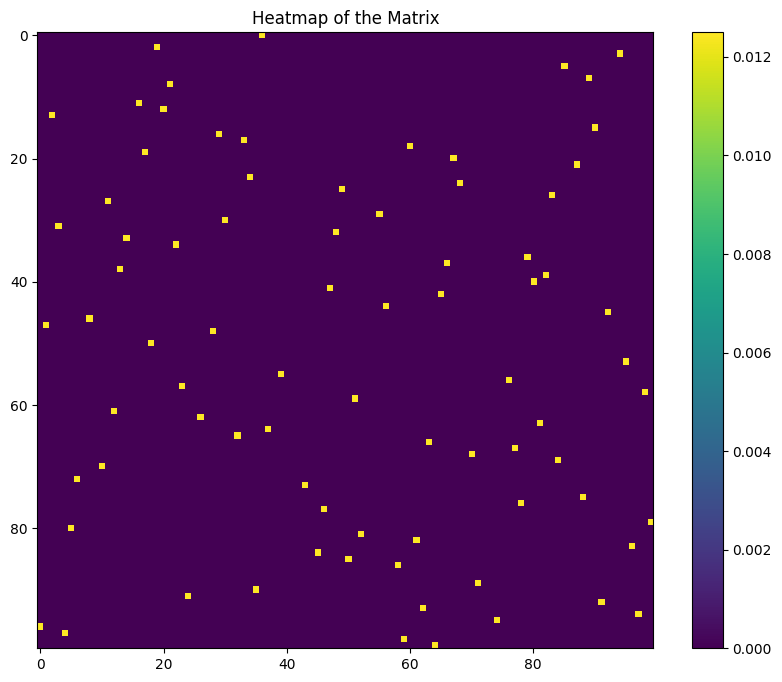

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Sample matrix for demonstration
matrix = explainer.wd.nu.numpy()

plt.figure(figsize=(10, 8))
plt.imshow(matrix, cmap='viridis')
plt.colorbar()
plt.title("Heatmap of the Matrix")
plt.show()
